# LeetCode #637: Average of Levels in Binary Tree

https://leetcode.com/problems/average-of-levels-in-binary-tree/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **DFS with depth tracking** | $O(n)$ | $O(n)$ |
| **Optimal: BFS Level Order ★** | $O(n)$ | $O(n)$ |

---

## Understanding the Methods

### DFS with depth tracking
DFS carries the current depth and accumulates per-level sums and counts in arrays. Requires $O(n)$ arrays and $O(h)$ stack — total $O(n)$ space but more bookkeeping.

### Optimal: BFS Level Order ★
Process the tree level by level using a queue. At each level, sum all node values and divide by the count. Naturally aligned with the problem structure — each BFS iteration corresponds exactly to one level.

**Why this is better than DFS:** BFS processes one complete level per iteration, so summing and averaging is trivial without extra index tracking.

**Constraints:**
* The number of nodes in the tree is in the range $[1, 10^4]$
* $-2^{31} \le \text{Node.val} \le 2^{31} - 1$


## Solutions

### C#

In [ ]:
public IList<double> AverageOfLevels(TreeNode root) {
    var result = new List<double>();
    var queue = new Queue<TreeNode>();
    queue.Enqueue(root);
    while (queue.Count > 0) {
        int sz = queue.Count; double sum = 0;
        // Accumulate sum of all nodes at the current level
        for (int i = 0; i < sz; i++) {
            var node = queue.Dequeue();
            sum += node.val;
            if (node.left  != null) queue.Enqueue(node.left);
            if (node.right != null) queue.Enqueue(node.right);
        }
        result.Add(sum / sz);
    }
    return result;
}

### Python

In [ ]:
from collections import deque

def average_of_levels(root) -> list[float]:
    result: list[float] = []
    queue = deque([root])
    while queue:
        sz = len(queue)
        level_sum = 0.0
        # Accumulate sum of all nodes at the current level
        for _ in range(sz):
            node = queue.popleft()
            level_sum += node.val
            if node.left:  queue.append(node.left)
            if node.right: queue.append(node.right)
        result.append(level_sum / sz)
    return result

### Go

In [ ]:
func averageOfLevels(root *TreeNode) []float64 {
    result := []float64{}
    queue := []*TreeNode{root}
    for len(queue) > 0 {
        sz := len(queue)
        sum := 0.0
        // Accumulate sum of all nodes at the current level
        for _, node := range queue {
            sum += float64(node.Val)
            if node.Left  != nil { queue = append(queue, node.Left) }
            if node.Right != nil { queue = append(queue, node.Right) }
        }
        queue = queue[sz:]
        result = append(result, sum/float64(sz))
    }
    return result
}

### Rust

In [ ]:
use std::collections::VecDeque;

pub fn average_of_levels(root: Option<Box<TreeNode>>) -> Vec<f64> {
    let mut result = vec![];
    let mut queue: VecDeque<&TreeNode> = VecDeque::new();
    if let Some(r) = &root { queue.push_back(r.as_ref()); }
    while !queue.is_empty() {
        let sz = queue.len();
        let mut sum = 0f64;
        // Accumulate sum of all nodes at the current level
        for _ in 0..sz {
            let node = queue.pop_front().unwrap();
            sum += node.val as f64;
            if let Some(l) = &node.left  { queue.push_back(l.as_ref()); }
            if let Some(r) = &node.right { queue.push_back(r.as_ref()); }
        }
        result.push(sum / sz as f64);
    }
    result
}

## Example Scenarios

**1. Common Case**
**Input:** `root = [3,9,20,null,null,15,7]`
Level 1: [3] → avg 3.0. Level 2: [9,20] → avg 14.5. Level 3: [15,7] → avg 11.0. Output: [3.0, 14.5, 11.0].

**2. Slightly Complex**
**Input:** `root = [3,9,20,15,7]`
Level 1: [3] → 3.0. Level 2: [9,20] → 14.5. Level 3: [15,7] (children of 9) → 11.0. Same output as example 1 since only topology changes.

**3. Edge Case: Time Factor**
**Input:** Perfect binary tree of height $h$ ($n = 2^h - 1$ nodes)
BFS visits all $n$ nodes. The widest level has $2^{h-1}$ nodes — the queue peaks at that size. Total: $O(n)$ dequeues and enqueues.

**4. Edge Case: Space Factor**
**Input:** Complete binary tree, last level nearly full
Queue holds up to $\lceil n/2 \rceil$ nodes simultaneously (the last level). For $n = 10^4$, queue peak $\approx$ 5,000 nodes — $O(n)$ space.

**5. Almost-Impossible but Plausible**
**Input:** Tree where a level has nodes with values near $\pm 2^{31}$
Level sum could overflow 32-bit integers. Using `double` (or `long` then divide) prevents overflow — the problem guarantees $\text{Node.val} \in [-2^{31}, 2^{31}-1]$, so the sum of $10^4$ such values can reach $\approx 2 \times 10^{13}$, safely within `double` precision.


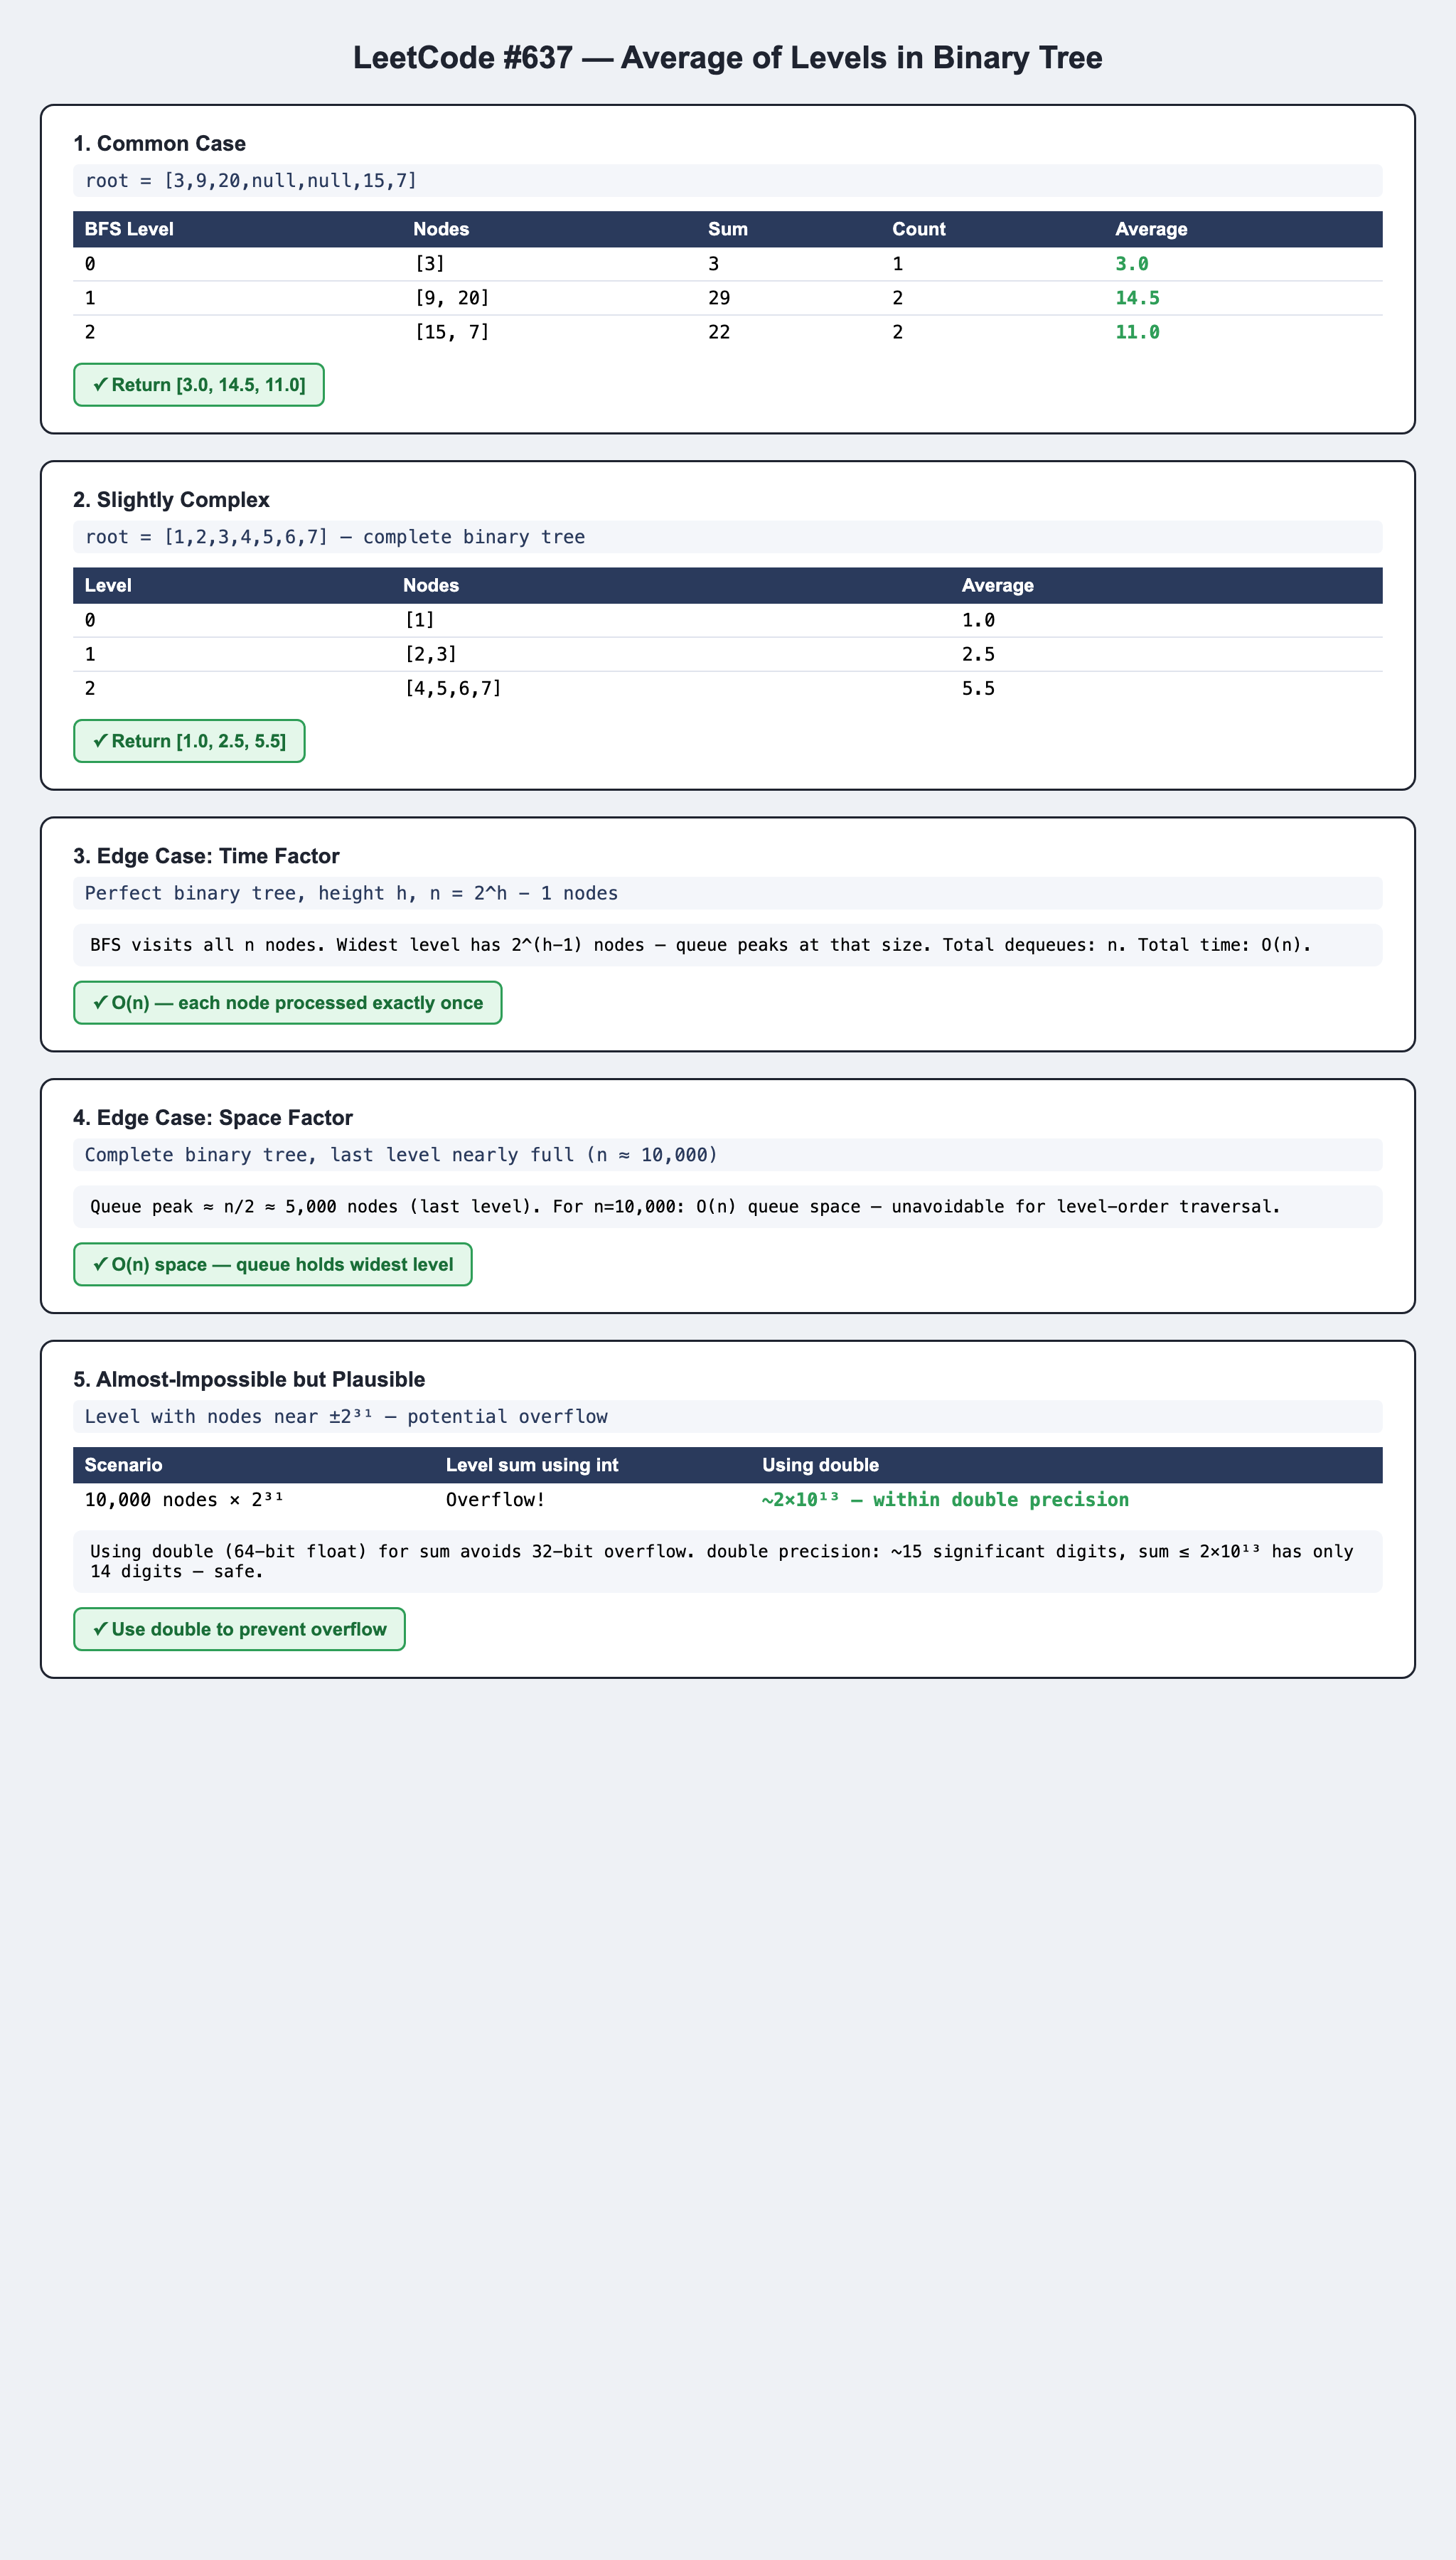